In [1]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import gca
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
def load_benchmark_directory(directory):
    df = None
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        filepath = os.path.join(directory, filename)
        
        curr_df = pd.read_csv(filepath)
        if df is None:
            df = curr_df
        else:
            df = pd.concat([df, curr_df])

    # sort df by gpu_count then slurm_job_id
    df = df.sort_values(by=['gpu_count', 'slurm_job_id']).reset_index(drop=True)
    return df

In [3]:
system = "perlmutter"

xccl_df = load_benchmark_directory("data/all_reduce/perlmutter/xccl")
# xccl_df = load_benchmark_directory("data/all_reduce/frontier/benchmark-2025-09-03/rccl")
xccl_df['time'] = xccl_df['time_xccl']
xccl_df['backend'] = 'xccl'
pccl_df = load_benchmark_directory("data/all_reduce/perlmutter/pccl1")
# pccl_df = load_benchmark_directory("data/all_reduce/frontier/benchmark-2025-09-03/pccl-rccl+mpi")
pccl_df['time'] = pccl_df['time_pccl_cpp_rec']
pccl_df['backend'] = 'pccl'

In [4]:
feats = ['gpu_count', 'output_size', 'backend', 'time']
pd.set_option('display.max_rows', None)
def highlight_backend(row):
    if row['backend'] == 'xccl':
        return ['background-color: none'] * len(row)
    elif row['backend'] == 'pccl':
        return ['background-color: green'] * len(row)
    else:
        return [''] * len(row)

# pd.concat([rccl_df, pccl_df]).sort_values(by=feats).reset_index()[feats].style.apply(highlight_backend, axis=1)


In [5]:
pd.reset_option('display.max_rows')

In [6]:
xccl_avg_time = xccl_df.groupby(['gpu_count', 'output_size'])['time'].mean().reset_index().rename(columns={'time': 'mean'})
pccl_avg_time = pccl_df.groupby(['gpu_count', 'output_size'])['time'].mean().reset_index().rename(columns={'time': 'mean'})

xccl_avg_time, pccl_avg_time

(    gpu_count  output_size        mean
 0          32            1    0.417821
 1          32            2    0.564922
 2          32            4    0.907409
 3          32            8    1.025476
 4          32           16    1.300271
 ..        ...          ...         ...
 73       1024          256   12.136504
 74       1024          512   22.134119
 75       1024         1024   43.825570
 76       1024         2048   87.615857
 77       1024         4096  154.453520
 
 [78 rows x 3 columns],
     gpu_count  output_size       mean
 0          32            1   0.522561
 1          32            2   0.557514
 2          32            4   0.644842
 3          32            8   0.779526
 4          32           16   1.059682
 ..        ...          ...        ...
 61       1024           64   4.753292
 62       1024          128   7.470525
 63       1024          256  13.411795
 64       1024          512  25.049725
 65       1024         1024  48.425340
 
 [66 rows x 3 columns])

In [7]:
# for any combination of exp_gpu_count, exp_output_size which doesn't have a value, put zero
exp_gpu_counts = [8, 16, 32, 64, 128, 256, 512, 1024, 2048]
exp_output_size = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]

# Create a complete grid of all combinations of exp_gpu_counts and exp_output_size
complete_grid = pd.DataFrame([(gpu, size) for gpu in exp_gpu_counts for size in exp_output_size],
                             columns=['gpu_count', 'output_size'])

# Merge the complete grid with xccl_avg_time and pccl_avg_time, filling missing values with zero
xccl_avg_time = complete_grid.merge(xccl_avg_time, on=['gpu_count', 'output_size'], how='left').fillna(0)
pccl_avg_time = complete_grid.merge(pccl_avg_time, on=['gpu_count', 'output_size'], how='left').fillna(0)

xccl_avg_time, pccl_avg_time

(    gpu_count  output_size  mean
 0           8            1   0.0
 1           8            2   0.0
 2           8            4   0.0
 3           8            8   0.0
 4           8           16   0.0
 ..        ...          ...   ...
 94       2048           64   0.0
 95       2048          128   0.0
 96       2048          256   0.0
 97       2048          512   0.0
 98       2048         1024   0.0
 
 [99 rows x 3 columns],
     gpu_count  output_size  mean
 0           8            1   0.0
 1           8            2   0.0
 2           8            4   0.0
 3           8            8   0.0
 4           8           16   0.0
 ..        ...          ...   ...
 94       2048           64   0.0
 95       2048          128   0.0
 96       2048          256   0.0
 97       2048          512   0.0
 98       2048         1024   0.0
 
 [99 rows x 3 columns])

In [8]:
def set_aspect_ratio(ratio=3/5, logx=None, logy=None, axis=None):
    if axis is None:
        axis = gca() 
    xleft, xright = axis.get_xlim()
    if logx is not None:
        xleft = math.log(xleft, logx)
        xright = math.log(xright, logx)
    ybottom, ytop = axis.get_ylim()
    if logy is not None:
        ytop = math.log(ytop, logy)
        print(ytop, ybottom)
        ybottom = math.log(ybottom, logy)
    axis.set_aspect(abs((xright-xleft)/(ybottom-ytop))*ratio)

def get_overlay_color(red, green, blue, alpha):
    if (red*0.299 + green*0.587 + blue*0.114)*alpha > 0.75:
        return "k"
    else:
        return "w"

"""
def visualize_speedup(df1,
                      df2,
                      name_of_file,
                      title,
                      minimum_message_size=0,
                      minimum_gpu_count=32,
                      bounds=[0.5, 0.75, 1, 2, 4, 8, 16],
                      colors=["#BD0026", "#FD8D3C", "#C7E9B4" , "#7FCDBB", "#41B6C4", "#2C7FB8", "#253494"]):
"""
def visualize_speedup(df1,
                      df2,
                      name_of_file,
                      title,
                      minimum_message_size=0,
                      minimum_gpu_count=32,
                      bounds=[0.5, 0.75, 1, 2, 4, 8, 16],
                      colors=["#BD0026", "#FD8D3C", "#C7E9B4" , "#7FCDBB", "#41B6C4", "#2C7FB8", "#253494"]):
    """
    Visualizes the speedup of df2 over df1 as a continuous heatmap with red (slower) and blue (faster).

    Args:
        df1 (pd.DataFrame): First DataFrame with columns ['gpu_count', 'output_size', 'mean'].
        df2 (pd.DataFrame): Second DataFrame with columns ['gpu_count', 'output_size', 'mean'].
    """
    plt.clf()
    # Filter by minimum message size
    df1 = df1[df1["output_size"] >= minimum_message_size]
    df2 = df2[df2["output_size"] >= minimum_message_size]

    # filter by minimum gpu count
    df1 = df1[df1["gpu_count"] >= minimum_gpu_count]
    df2 = df2[df2["gpu_count"] >= minimum_gpu_count]

    # Merge both DataFrames on gpu_count and output_size
    merged_df = df1.merge(df2, on=['gpu_count', 'output_size'], suffixes=('_df1', '_df2'))

    # Compute speedup (df2 over df1)
    merged_df['speedup'] = merged_df['mean_df1'] / merged_df['mean_df2']

    # Extract unique values for plotting
    gpu_counts = sorted(merged_df['gpu_count'].unique())
    output_sizes = sorted(merged_df['output_size'].unique())

    # Create a grid for speedup values
    speedup_grid = np.full((len(output_sizes), len(gpu_counts)), np.nan)


    # Map (gpu_count, output_size) to grid positions
    gpu_to_idx = {gpu: i for i, gpu in enumerate(gpu_counts)}
    output_to_idx = {out: i for i, out in enumerate(output_sizes)}

    for _, row in merged_df.iterrows():
        gpu_idx = gpu_to_idx[row['gpu_count']]
        output_idx = output_to_idx[row['output_size']]
        speedup_grid[output_idx, gpu_idx] = row['speedup']


    # **Fix Color Normalization (Log Scale)**
    #speedup_grid = np.log2(speedup_grid)  # Log-scale the speedup values

    # Use a diverging colormap with a better balance
    # lim = max(abs(np.nanmin(speedup_grid)), abs(np.nanmax(speedup_grid)))
    # divnorm = mcolors.TwoSlopeNorm(vmin=-lim, vcenter=0, vmax=lim)

    # Define custom bounds and corresponding colors
    #bounds = [0.5, 1, 2, 5, 10, 20, 40]

    #colors = ["#BD0026"] + ["#253494", "#2C7FB8", "#41B6C4", "#7FCDBB", "#C7E9B4", "#FFFFCC"][::-1]  # Your color scheme


    # Create colormap and normalization
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, ncolors=cmap.N, extend="max")

    #cmap = mpl.colormaps.get_cmap("seismic_r")
    ## center norm at 1 so colormap is aligned properly
    vmin = speedup_grid.min(axis=None)
    vmax = speedup_grid.max(axis=None)
    print(f"{title}:\n  min={vmin}, max={vmax}")
    #if 1/vmin <= vmax:
    #    vmax = 2**np.ceil(np.log2(vmax))
    #    vmin = 1/vmax
    #else:
    #    vmin = 2**np.floor(np.log2(vmin))
    #    vmax = 1/vmin
    #norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)

    # Plot the heatmap with improved color balance
    fig, ax = plt.gcf(), plt.gca()
    #cax = ax.imshow(speedup_grid, aspect='auto', cmap='RdBu_r', norm=divnorm, origin='lower')
    cax = ax.pcolor(speedup_grid, cmap=cmap, norm=norm, edgecolors='white', linewidth=1.0)

    for i in range(speedup_grid.shape[0]):
        for j in range(speedup_grid.shape[1]):
            val = speedup_grid[i, j]
            fmt = "{val:0.2}"
            color = get_overlay_color(*cmap(norm(val)))

            if val >= 10:
                fmt = "{val:0.1f}"
            text = ax.text(j + 0.5, i + 0.45, fmt.format(val=val),
                           ha="center", va="center", color=color, fontsize=10)

    # Add colorbar
    cbar = fig.colorbar(cax, ax=ax, shrink=0.6, aspect=30, pad=0.02)

    # Make limits symmetric
    #min_log = np.log2(vmin)
    #max_log = np.log2(vmax)

    #print(vmin, vmax)
    #print(min_log, max_log)

    # Generate tick locations dynamically within the range
    #log_tick_locations = np.arange(min_log, max_log, step=1)  # Step size can be adjusted
    #abs_tick_labels = 2.0**log_tick_locations  # Convert to absolute speedup values
    #print(abs_tick_labels)
    #cbar.set_ticks(abs_tick_labels)
    #cbar.set_ticklabels(abs_tick_labels)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels([str(b) for b in bounds], fontsize=12)  # Format labels

    # # Apply ticks and labels to colorbar
    # cbar.set_ticks(log_tick_locations)
    # cbar.set_ticklabels([f"{v:.2f}" for v in abs_tick_labels], fontsize=12)  # Format labels
    # #cbar.set_label("Absolute Speedup (df2 over df1)", fontsize=12)

    # Set axis labels and ticks
    ax.set_xticks(np.arange(len(gpu_counts))+0.5)
    ax.set_xticklabels(gpu_counts, fontsize=12)
    ax.set_yticks(np.arange(len(output_sizes))+0.5)
    ax.set_yticklabels(output_sizes, fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)


    if "NCCL" in title:
        ax.set_xlabel("Number of processes (GPUs)", fontsize=14)
    else:
        ax.set_xlabel("Number of processes (GCDs)", fontsize=14)

    if '_ar' in name_of_file:
        ax.set_ylabel("Buffer size (MB)")
    elif "ag" in name_of_file and "rs" not in name_of_file:
        ax.set_ylabel("Output buffer size (MB)")
    elif "rs" in name_of_file and "ag" not in name_of_file:
        ax.set_ylabel("Input buffer size (MB)")

    ax.set_title(f"{title}\n", fontsize=14)
    ax.grid(which="minor", color="white", linestyle="-", linewidth=1)
    ax.tick_params(which='minor', bottom=False, top=False, left=False, right=False)
    ax.tick_params(axis='y', color='white', labelcolor='black')
    ax.tick_params(axis='x', color='white', labelcolor='black')

    # Save the plot
    set_aspect_ratio(3/5)
    plt.savefig(f"{name_of_file}.pdf", bbox_inches='tight')
    #plt.show()

Speedup of PCCL over RCCL for all-reduce (Perlmutter):
  min=nan, max=nan


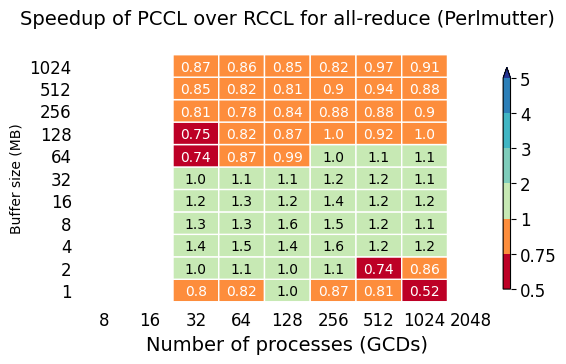

In [9]:
visualize_speedup(xccl_avg_time, pccl_avg_time, f"heatmap_pccl(rccl+mpi)_rccl_ar_{system}", f"Speedup of PCCL over RCCL for all-reduce ({system.title()})", minimum_message_size=0, minimum_gpu_count=0, bounds=[0.5, 0.75, 1, 2, 3, 4, 5],)

Speedup of PCCL over RCCL for all-reduce (Perlmutter):
  min=nan, max=nan


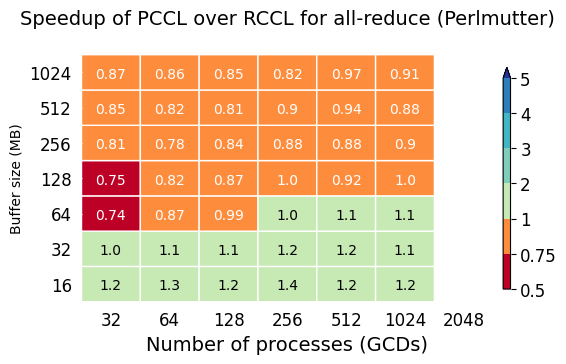

In [10]:
visualize_speedup(xccl_avg_time, pccl_avg_time, f"heatmap_pccl(rccl+mpi)_rccl_ar_{system}", f"Speedup of PCCL over RCCL for all-reduce ({system.title()})", minimum_message_size=16, minimum_gpu_count=32, bounds=[0.5, 0.75, 1, 2, 3, 4, 5],)